In [1]:
pip install requests beautifulsoup4 pandas

In [4]:
pip install selenium webdriver-manager pandas

In [8]:
!apt-get update
!apt-get install -y wget unzip
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install -y ./google-chrome-stable_current_amd64.deb


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,935 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,879 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,794 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,165 kB]
Get:14 http://archive.ubu

In [14]:
import pandas as pd
import requests
from io import StringIO

url = "https://slepchiloe.gob.cl/establecimientos-educacionales/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

html = StringIO(response.text)

tablas = pd.read_html(html)

df = tablas[0]

print("Cantidad de filas:", len(df))
print(df.head())

df.to_csv("colegios_chiloe.csv", index=False)

print("\nDatos guardados correctamente ✅")

Cantidad de filas: 157
                     Nombre establecimiento    Comuna  \
0                            Escuela Pudeto     Ancud   
1               Escuela Rural San Francisco  Quinchao   
2  Escuela Rural Teresa Cárdenas de Paredes  Quinchao   
3                  Escuela Rural La Capilla  Quinchao   
4                   Escuela Rural Los Pinos  Quinchao   

                     Dirección Telefono  Sitio web  
0        General Baquedano 183      NaN  Ver sitio  
1                  Isla Meulín      NaN   No tiene  
2  SECTOR RURAL VILLA QUINCHAO      NaN   No tiene  
3                 Isla Cahuach      NaN   No tiene  
4                 Isla Lin Lin      NaN   No tiene  

Datos guardados correctamente ✅


In [15]:
print("\nCantidad por comuna:")
print(df["Comuna"].value_counts())


Cantidad por comuna:
Comuna
Quellón            32
Ancud              22
Quemchi            22
Castro             19
Chonchi            14
Quinchao           11
Dalcahue           10
Queilén            10
Curaco de Vélez     9
Puqueldón           8
Name: count, dtype: int64


In [16]:
conteo_comunas = df["Comuna"].value_counts()

print(conteo_comunas)

Comuna
Quellón            32
Ancud              22
Quemchi            22
Castro             19
Chonchi            14
Quinchao           11
Dalcahue           10
Queilén            10
Curaco de Vélez     9
Puqueldón           8
Name: count, dtype: int64


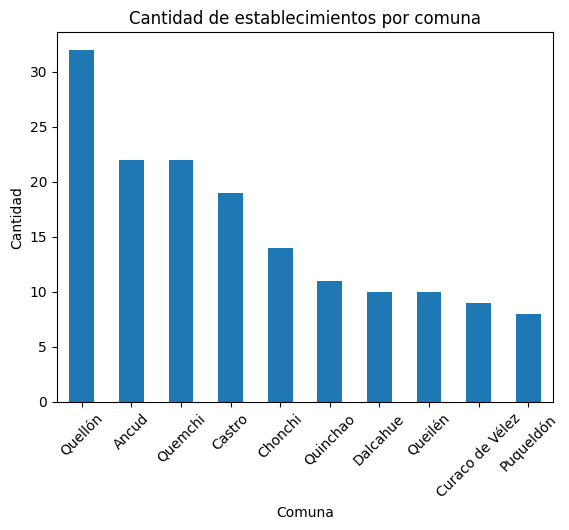

In [17]:
import matplotlib.pyplot as plt

conteo_comunas.plot(kind="bar")
plt.title("Cantidad de establecimientos por comuna")
plt.xlabel("Comuna")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

In [19]:
sin_web = df[df["Sitio web"] == "No tiene"]

print("Colegios sin sitio web:", len(sin_web))

Colegios sin sitio web: 150


In [20]:
print("Teléfonos faltantes:", df["Telefono"].isna().sum())

Teléfonos faltantes: 65
